### Building Chatbot with multiple tools using langgraph

#### AIM :- 
Create a chatbot with tool capabilites from arxiv , wikipedia and some functions .

In [37]:
from langchain_community.tools import ArxivQueryRun , WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper , ArxivAPIWrapper

In [38]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2 , doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [39]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [40]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=2 , doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wiki.name)

wikipedia


In [41]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed.\nStatistics and mathematical optimisation methods compose the foundations of machine learning. Data mining is a related field of study, focusing on exploratory data analysis (EDA) through unsupervised learning.\nFrom '

In [42]:
import os 
from dotenv import load_dotenv
load_dotenv()

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [43]:
from langchain_tavily import TavilySearch

tool = TavilySearch(
    max_results=5,
    topic="general",
)

In [44]:
tool.invoke({"query": "What happened at the last wimbledon"})

{'query': 'What happened at the last wimbledon',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://en.wikipedia.org/wiki/Wimbledon_Championships',
   'title': 'Wimbledon Championships - Wikipedia',
   'content': 'The tournament traditionally takes place over two weeks in late June and early July, starting either on the last Monday in June or the first Monday in July and culminating with the Ladies\' and Gentlemen\'s Singles Finals, scheduled for the Saturday and Sunday at the end of the second week. Five major events are held each year, with additional junior and invitational competitions also taking place. The tournament was not held during World War II, and was cancelled in 2020 due to the COVID-19 [...] while the women\'s singles champion received £750 (equivalent to £11,500 in 2025). In 2007, Wimbledon and the French Open became the last grand slam tournaments to award unequal prize money to women and men. [...] Before 2022, the second Mond

In [45]:
### Combile all the tools in the list 

tools = [arxiv,wiki,tool]

In [48]:
### Initialize my llm model 
from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = ChatGroq(model="openai/gpt-oss-120b",)  # or the exact Groq model identifier
llm_with_tools = llm.bind_tools(tools)


In [49]:
from langchain_core.messages import HumanMessage , AIMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI news")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is the recent AI news". Need to provide recent AI news. We should browse current news. Use tavily_search with query "recent AI news" maybe limit to last week. Use time_range "week".', 'tool_calls': [{'id': 'fc_9324af44-0f43-482e-8027-3f9ac594b308', 'function': {'arguments': '{"query":"AI news September 2026","time_range":"week","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 98, 'prompt_tokens': 450, 'total_tokens': 548, 'completion_time': 0.204792176, 'completion_tokens_details': {'reasoning_tokens': 49}, 'prompt_time': 0.018125351, 'prompt_tokens_details': None, 'queue_time': 0.212060887, 'total_time': 0.222917527}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_6dedd2be22', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0946b-321f-7070-bb7

In [50]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI news")]).tool_calls

[{'name': 'tavily_search',
  'args': {'query': 'AI news September 2026',
   'search_depth': 'advanced',
   'time_range': 'week',
   'topic': 'news'},
  'id': 'fc_e5ff5904-5ae1-4505-8450-3a41b27ba68f',
  'type': 'tool_call'}]

In [51]:
### State 
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

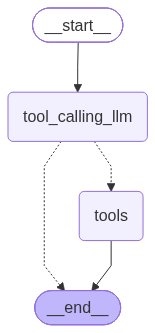

In [56]:
### Entire ChatBot With Langgraph 
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


### Node Defination 
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}


builder = StateGraph(State)

builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START ,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
)

builder.add_edge("tools",END)

graph_builder = builder.compile()
display(Image(graph_builder.get_graph().draw_mermaid_png()))


In [58]:
messages = graph_builder.invoke({"messages":HumanMessage(content="What is attention is all you need")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is attention is all you need
================================== Ai Message ==================================

**“Attention Is All You Need”** is the title of a landmark research paper (Vaswani et al., 2017) that introduced the **Transformer** architecture – a new way of building neural networks for sequence‑to‑sequence tasks such as machine translation, summarisation, and many other natural‑language‑processing (NLP) problems.

Below is a concise, non‑technical overview of what the paper proposes, why it mattered, and how the core ideas work.

---

## 1. The problem the paper was trying to solve
Traditional sequence models (RNNs, LSTMs, GRUs) process tokens **one‑by‑one** and keep a hidden state that “remembers” the past. This design has two major drawbacks:

| Issue | Why it matters |
|-------|----------------|
| **Sequential bottleneck** | Tokens can’t be processed in parallel, making training slow

In [59]:
messages = graph_builder.invoke({"messages":HumanMessage(content="Provide me with top 10 AI recent news on September 9 2026")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me with top 10 AI recent news on September 9 2026
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_8910db3d-b07f-4cec-a698-279352d85e84)
 Call ID: fc_8910db3d-b07f-4cec-a698-279352d85e84
  Args:
    query: AI news September 9 2026
    search_depth: advanced
    time_range: day
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news September 9 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"title": "AI News Briefs BULLETIN BOARD for September 2026 – Radical Data Science", "url": "https://radicaldatascience.wordpress.com/2026/09/11/ai-news-briefs-bulletin-board-for-september-2026", "content": "[9/9/2026] Introducing Muse: The World’s First Personal AI Agent Built for Everyone – Meta introduces Muse, a personal AI agent, powered by Muse Spar